<hr>

# 📈 DATA ANALYSIS


<style>
h1 {
    text-align: left;
    color: blue;
    font-weight: bold;
}

</style>
<hr>

```text
Types of Analysis:
- Univariat
- Bivariat (feature vs target)
- Multivariat (mulitple feautures vs target)
- Correlation Matrix
- Outliers
```

<style>
h3 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

### 📂 IMPORTs

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200) # to display all columns in the dataframe

<hr>

## 0 - DATA OBSERVATION


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

### **SHAPE & HEAD**

In [ ]:
import pandas as pd

FILE = "../data/processed/CLEAN_ValeursFoncieres.csv"
CHUNK_SIZE = 50_000

total_rows = 0
columns = None

for chunk in pd.read_csv(FILE, chunksize=CHUNK_SIZE, dtype=str):
    total_rows += len(chunk)
    if columns is None:
        columns = chunk.columns

print("Shape:", total_rows, "rows and", len(columns), "columns")

df_head = pd.read_csv(FILE, nrows=5, dtype=str)
display(df_head)


### **INFO**

In [ ]:
import pandas as pd

FILE = "../data/processed/CLEAN_ValeursFoncieres.csv"
CHUNK_SIZE = 50_000

total_rows = 0
columns = None
non_null_counts = None
dtypes = None

for chunk in pd.read_csv(FILE, chunksize=CHUNK_SIZE, dtype=str):
    if columns is None:
        columns = chunk.columns.tolist()
        non_null_counts = {col: 0 for col in columns}
        dtypes = chunk.dtypes.astype(str).to_dict()

    total_rows += len(chunk)

    for col in columns:
        non_null_counts[col] += chunk[col].notna().sum()

# Build info-style summary
info_df = pd.DataFrame({
    "column": columns,
    "non_null_count": [non_null_counts[col] for col in columns],
    "null_count": [total_rows - non_null_counts[col] for col in columns],
    "dtype": [dtypes[col] for col in columns]
})

print(f"RangeIndex: {total_rows} entries, 0 to {total_rows - 1}")
print(f"Data columns (total {len(columns)} columns):")
display(info_df)
print(f"dtypes: {info_df['dtype'].value_counts().to_dict()}")
print(f"memory usage: not computed (chunked mode)")

### **UNIQUE VALUES**

In [ ]:
from collections import defaultdict
import pandas as pd

FILE = "../data/processed/CLEAN_ValeursFoncieres.csv"

unique_values = defaultdict(set)
null_counts = defaultdict(int)

for chunk in pd.read_csv(FILE, chunksize=50_000, dtype=str):
    for col in chunk.columns:
        null_counts[col] += chunk[col].isna().sum()
        unique_values[col].update(chunk[col].fillna("MISSING").unique())

print(100*"-")
for col in unique_values:
    print(f"\n➡️ {col}:")
    print(f"Unique values count:{len(unique_values[col])}")
    print(f"Null count: {null_counts[col]}")
    print(f"Unique values: {list(unique_values[col])[:120]}")
    print(100*"-")

### 🆔 **IDENTIFY - Numerical / Categorical Columns**

In [ ]:
# Define columns numerical / categorical

num_cols = [
    '', 
    'col_5', 
    'col_6'
]

cat_cols = [
    'col_1',
    'col_2',
    'col_4'
]


# Display NUMERICAL and CATEGORICAL COLUMNS
print("Numerical columns:")
display(num_cols)
print(100*"-")

print("Categorical columns:")
display(cat_cols)
print(100*"-")

print("Date columns:")
display(date_cols)
print(100*"-")


<hr>

## 1 - UNIVARIAT ANALYSIS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

It's the simplest form of data analysis that deals with only one variable at a time, either in an inferential or descriptive manner

<hr>

## 2 - BIVARIAT ANALYSIS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

It's a statistical technique used to analyze the relationship between two variables

<style>
h3 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
    color: black;
}
</style>

### A) FEATURE vs TARGET (transaction_value)

<style>
h4 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

#### 🏷️ Categorical vs 🎯 Target

<style>
h4 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

#### 🔢 Numerical vs 🎯 Target

<style>
h3 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
    color: black;
}
</style>

### B) FEATURE vs FEATURE

<style>
h4 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

#### 🏷️ Categorical vs 🏷️ Categorical

<style>
h4 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

#### 🔢 Numerical vs 🔢 Numerical

<style>
h4 {
    margin-top: 0px;
    margin-bottom: 0px;
    font-weight: bold;
}
</style>

#### 🏷️ Categorical vs 🔢 Numerical (vice versa)

<hr>

## 3 - MULTIVARIAT ANALYSIS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

It's a collection of statistical techniques used to analyze data sets with multiple correlated variables

### **ALL FEATURES vs TARGET `transaction_value`**

In [ ]:
# scatter plot each feature vs target variable

In [ ]:
# correlation matrix heatmap plot

<hr>

## 4 - OUTLIERS ANALYSIS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

 An outlier is an observation that lies an abnormal distance from other values in a random sample from a population

<hr>

## 5 - CORRELATION ANALYSIS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

It's a statistical method that is used to discover if there is a relationship between two variables/datasets, and how strong that relationship may be

<hr>

## TRENDS


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

#### **PLOT : Linear chart for 5-6 years TRENDS(Date mutation) Type local(line coloured) vs Valeur fonciere(y-axis)**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert date
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

# Keep only useful rows
df = df.dropna(subset=["property_value", "property_type"])

# Optional: remove extreme outliers (recommended)
df = df[df["property_value"] < 2_000_000]

# Create year-month column
df["year_month"] = df["transaction_date"].dt.to_period("M")

# Aggregate: mean price per month per property type
df_grouped = df.groupby(["year_month", "property_type"])["property_value"].mean().reset_index()

# Convert back to timestamp for plotting
df_grouped["year_month"] = df_grouped["year_month"].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))

for property_type in df_grouped["property_type"].unique():
    subset = df_grouped[df_grouped["property_type"] == property_type]
    plt.plot(subset["year_month"], subset["property_value"], label=property_type)

plt.xlabel("Date")
plt.ylabel("Average Property Price (€)")
plt.title("Property Price and Type 2020-2025")
plt.legend()
plt.grid()

plt.show()

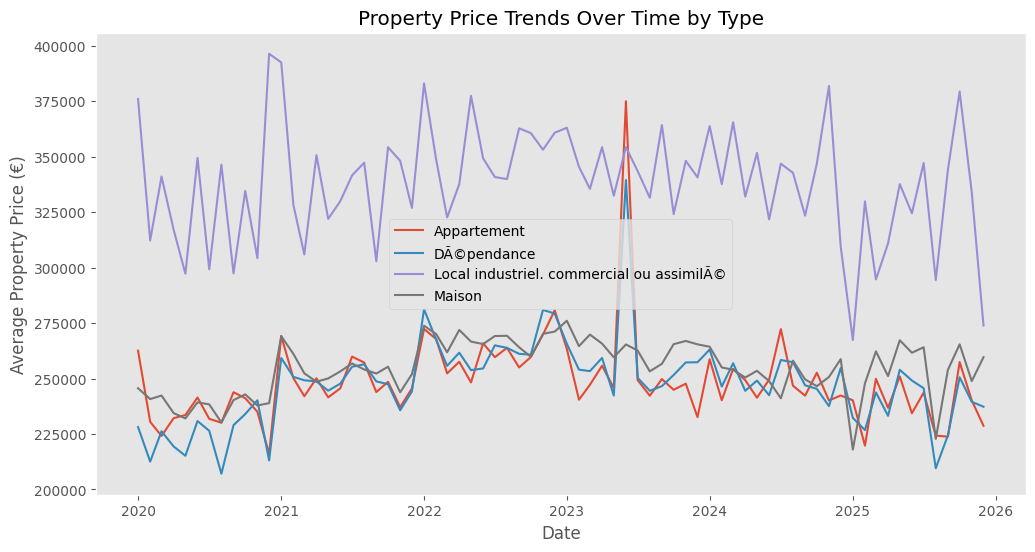

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert date
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only useful rows
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers (recommended)
df = df[df["Valeur fonciere"] < 2_000_000]

# Create year-month column
df["year_month"] = df["Date mutation"].dt.to_period("M")

# Aggregate: mean price per month per property type
df_grouped = df.groupby(["year_month", "Type local"])["Valeur fonciere"].mean().reset_index()

# Convert back to timestamp for plotting
df_grouped["year_month"] = df_grouped["year_month"].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))

for property_type in df_grouped["Type local"].unique():
    subset = df_grouped[df_grouped["Type local"] == property_type]
    plt.plot(subset["year_month"], subset["Valeur fonciere"], label=property_type)

plt.xlabel("Date")
plt.ylabel("Average Property Price (€)")
plt.title("Property Price Trends Over Time by Type")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Convert date
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant rows
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Filter only Maison & Appartement
df = df[df["Type local"].isin(["Maison", "Appartement"])]

# Create year-month column
df["year_month"] = df["Date mutation"].dt.to_period("M")
df_grouped = df.groupby(["year_month", "Type local"])["Valeur fonciere"].mean().reset_index()

# Convert back to timestamp for plotting
df_grouped["year_month"] = df_grouped["year_month"].dt.to_timestamp()

# Colors for property types
colors = {'Maison': '#4C78A8', 'Appartement': '#F58518'}

# Plotly figure
fig = go.Figure()
for prop_type in ["Maison", "Appartement"]:
    subset = df_grouped[df_grouped["Type local"] == prop_type]
    fig.add_trace(go.Scatter(
        x=subset["year_month"],
        y=subset["Valeur fonciere"],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[prop_type], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Date: %{{x|%b %Y}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

fig.update_layout(
    title='Property Price Trends Over Time by Type',
    xaxis_title="Date",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

fig.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Prepare Plotly colors (soft, distinct)
colors_palette = [
    '#4C78A8', '#F58518', '#E45756', '#72B7A3', '#54A24B', '#EECA3B',
    '#B279A2', '#FF9DA7', '#9D755D', '#BAB0AC', '#8EBA42', '#4DBBD5'
]
property_types = monthly_avg['Type local'].unique()
colors = {ptype: colors_palette[i % len(colors_palette)] for i, ptype in enumerate(property_types)}

# Plotly figure
fig = go.Figure()
for prop_type in property_types:
    subset = monthly_avg[monthly_avg['Type local'] == prop_type]
    fig.add_trace(go.Scatter(
        x=subset['Month_Name'],
        y=subset['Valeur fonciere'],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[prop_type], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Month: %{{x}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

fig.update_layout(
    title='Seasonal Trends: Average Property Price per Month (5-Year Avg)',
    xaxis_title="Month",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(tickangle=0)
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

fig.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years:")
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

Monthly averages across 5 years:
Type local  Appartement    Maison
Month_Name                       
January        266449.0  266889.0
February       247497.0  259443.0
March          245315.0  257244.0
April          249979.0  255971.0
May            243792.0  255363.0
June           280849.0  256385.0
July           254879.0  257358.0
August         251298.0  254998.0
September      246545.0  253474.0
October        250666.0  255920.0
November       247866.0  255282.0
December       247065.0  259165.0


#### **PLOT : Linear chart 2020-2025 PROPERTY_TYPE/PRICE TRENDS (price per m²)**

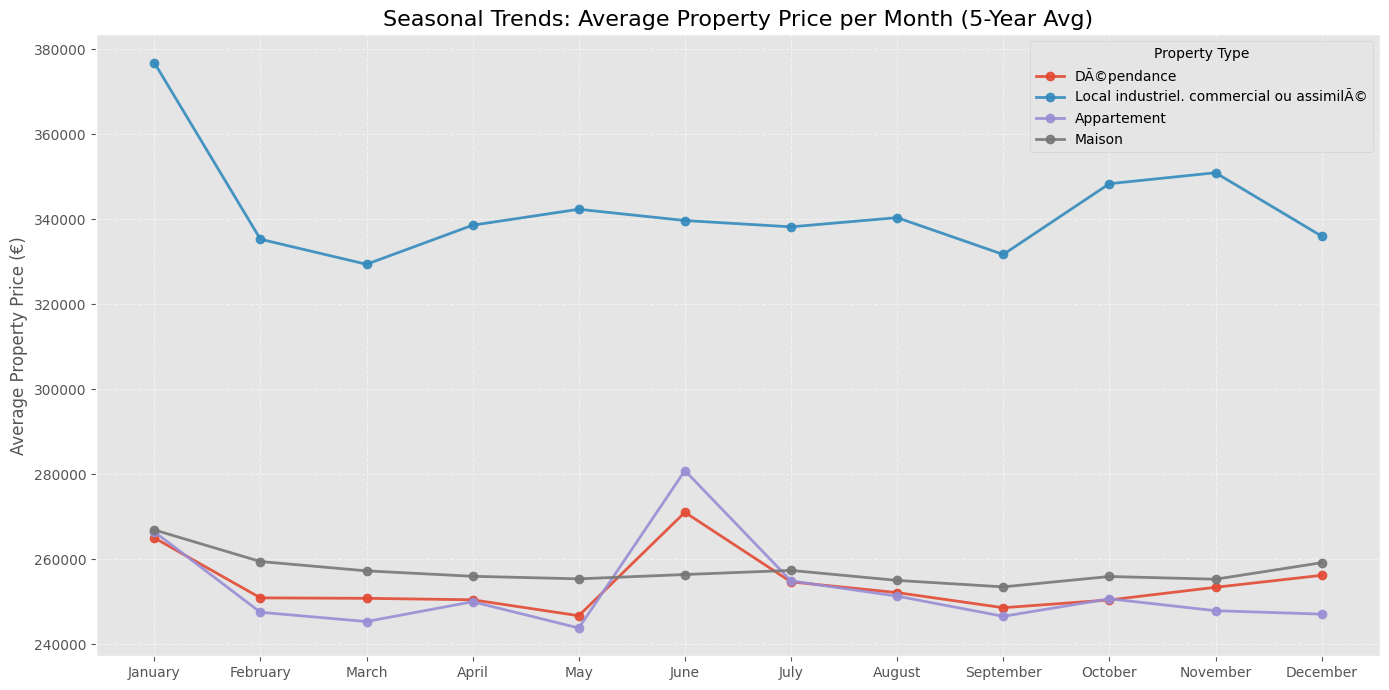

Monthly averages across 5 years:
Type local  Appartement  DÃ©pendance  \
Month_Name                             
January        266449.0     265015.0   
February       247497.0     250887.0   
March          245315.0     250781.0   
April          249979.0     250435.0   
May            243792.0     246682.0   
June           280849.0     271031.0   
July           254879.0     254650.0   
August         251298.0     252130.0   
September      246545.0     248569.0   
October        250666.0     250399.0   
November       247866.0     253379.0   
December       247065.0     256194.0   

Type local  Local industriel. commercial ou assimilÃ©    Maison  
Month_Name                                                       
January                                      376903.0  266889.0  
February                                     335323.0  259443.0  
March                                        329423.0  257244.0  
April                                        338628.0  255971.0  
May       

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Plot
plt.figure(figsize=(14,7))
for property_type in monthly_avg['Type local'].unique():
    subset = monthly_avg[monthly_avg['Type local'] == property_type]
    plt.plot(subset['Month_Name'], subset['Valeur fonciere'],
             marker='o', linewidth=2, alpha=0.9, label=property_type)

plt.title("Seasonal Trends: Average Property Price per Month (5-Year Avg)", fontsize=16)
plt.ylabel("Average Property Price (€)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Property Type")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years:") # seasonal trends 
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Unique property types
property_types = monthly_avg['Type local'].unique()

# Eye-friendly colors (repeat if more types than colors)
colors_palette = [
    '#4C78A8', '#F58518', '#E45756', '#72B7A3', '#54A24B', '#EECA3B',
    '#B279A2', '#FF9DA7', '#9D755D', '#BAB0AC', '#8EBA42', '#4DBBD5'
]
colors = {ptype: colors_palette[i % len(colors_palette)] for i, ptype in enumerate(property_types)}

# Create Plotly figure
fig = go.Figure()
for prop_type in property_types:
    subset = monthly_avg[monthly_avg['Type local'] == prop_type]
    fig.add_trace(go.Scatter(
        x=subset['Month_Name'],
        y=subset['Valeur fonciere'],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[prop_type], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Month: %{{x}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

# Update layout to match Matplotlib style
fig.update_layout(
    title='Seasonal Trends: Average Property Price per Month (5-Year Avg)',
    xaxis_title="Month",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(tickangle=0, showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

fig.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years:")
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

Monthly averages across 5 years:
Type local  Appartement    Maison
Month_Name                       
January        266449.0  266889.0
February       247497.0  259443.0
March          245315.0  257244.0
April          249979.0  255971.0
May            243792.0  255363.0
June           280849.0  256385.0
July           254879.0  257358.0
August         251298.0  254998.0
September      246545.0  253474.0
October        250666.0  255920.0
November       247866.0  255282.0
December       247065.0  259165.0


#### **PLOT : PURCHASE AVG Maison vs Appartement**
Linear chart MONTHLY TRENDS PROPERTY_TYPE/PRICE TRENDS (MAISON vs APPARTEMENT)

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Convert date column
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep only relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Extract month name
df['Month_Name'] = df['Date mutation'].dt.month_name()

# Calculate average price per month for each Type local
monthly_avg = df.groupby(['Type local', 'Month_Name'])['Valeur fonciere'].mean().reset_index()

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Sort by month order
monthly_avg['Month_Name'] = pd.Categorical(monthly_avg['Month_Name'], categories=month_order, ordered=True)
monthly_avg = monthly_avg.sort_values('Month_Name')

# Get all unique property types in dataset
property_types = monthly_avg['Type local'].unique()

# Eye-friendly colors (repeat if more types than colors)
colors_palette = [
    '#4C78A8', '#F58518', '#E45756', '#72B7A3', '#54A24B', '#EECA3B',
    '#B279A2', '#FF9DA7', '#9D755D', '#BAB0AC', '#8EBA42', '#4DBBD5'
]
colors = {ptype: colors_palette[i % len(colors_palette)] for i, ptype in enumerate(property_types)}

# Plotly figure
fig = go.Figure()
for prop_type in property_types:
    subset = monthly_avg[monthly_avg['Type local'] == prop_type]
    fig.add_trace(go.Scatter(
        x=subset['Month_Name'],
        y=subset['Valeur fonciere'],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[prop_type], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Month: %{{x}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

# Layout
fig.update_layout(
    title='Seasonal Trends: Average Property Price per Month (5-Year Avg) — All Property Types',
    xaxis_title="Month",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(tickangle=0, showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

fig.show()

# Optional: print the monthly averages table
print("Monthly averages across 5 years:")
print(monthly_avg.pivot(index='Month_Name', columns='Type local', values='Valeur fonciere').round(0))

Monthly averages across 5 years:
Type local  Appartement    Maison
Month_Name                       
January        266449.0  266889.0
February       247497.0  259443.0
March          245315.0  257244.0
April          249979.0  255971.0
May            243792.0  255363.0
June           280849.0  256385.0
July           254879.0  257358.0
August         251298.0  254998.0
September      246545.0  253474.0
October        250666.0  255920.0
November       247866.0  255282.0
December       247065.0  259165.0


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Convert date
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# Keep relevant columns and drop missing
df = df.dropna(subset=["Valeur fonciere", "Type local"])

# Optional: remove extreme outliers
df = df[df["Valeur fonciere"] < 2_000_000]

# Filter only Maison & Appartement
df = df[df["Type local"].isin(["Maison", "Appartement"])]

# Extract month names and short names
full_to_short = {
    'January': 'Jan', 'February': 'Feb', 'March': 'Mar', 'April': 'Apr',
    'May': 'May', 'June': 'Jun', 'July': 'Jul', 'August': 'Aug',
    'September': 'Sep', 'October': 'Oct', 'November': 'Nov', 'December': 'Dec'
}
df['Month_Name'] = df['Date mutation'].dt.month_name()
df['Month_Short'] = df['Month_Name'].map(full_to_short)

# Define month order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Compute 5-year monthly averages per property type
monthly_data = {}
for prop_type in ["Maison", "Appartement"]:
    monthly_avg = df[df["Type local"] == prop_type].groupby("Month_Short")["Valeur fonciere"].mean().reset_index()
    monthly_avg['Month_Short'] = pd.Categorical(monthly_avg['Month_Short'], categories=month_order, ordered=True)
    monthly_avg = monthly_avg.sort_values("Month_Short")
    monthly_data[prop_type] = monthly_avg.set_index("Month_Short")["Valeur fonciere"]

# Combine into DataFrame
monthly_df = pd.DataFrame(monthly_data).reindex(month_order)

# Colors for the two types
colors = ['#4C78A8', '#F58518']  # Maison = blue, Appartement = orange

# Plotly figure
fig = go.Figure()
for i, prop_type in enumerate(["Maison", "Appartement"]):
    fig.add_trace(go.Scatter(
        x=monthly_df.index,
        y=monthly_df[prop_type],
        mode='lines+markers',
        name=prop_type,
        line=dict(color=colors[i], width=3),
        marker=dict(size=8),
        hovertemplate=f'<b>{prop_type}</b><br>Month: %{{x}}<br>Avg Price: €%{{y:,.0f}}<extra></extra>'
    ))

fig.update_layout(
    title='Property Price Trends - Seasonal 5-Year Monthly Averages',
    xaxis_title="",
    yaxis_title="Average Property Price (€)",
    hovermode='x unified',
    legend=dict(title="Property Type", yanchor="top", y=1.0, xanchor="left", x=1.02),
    width=1200,
    height=600,
    plot_bgcolor='white',
    font=dict(size=12)
)

fig.update_xaxes(tickangle=0)
fig.update_yaxes(gridcolor='lightgray')

fig.show()

# Optional: print monthly averages table
print("✅ Seasonal 5-Year Monthly Averages (Maison & Appartement):")
print(monthly_df.round(0))

✅ Seasonal 5-Year Monthly Averages (Maison & Appartement):
               Maison  Appartement
Month_Short                       
Jan          266889.0     266449.0
Feb          259443.0     247497.0
Mar          257244.0     245315.0
Apr          255971.0     249979.0
May          255363.0     243792.0
Jun          256385.0     280849.0
Jul          257358.0     254879.0
Aug          254998.0     251298.0
Sep          253474.0     246545.0
Oct          255920.0     250666.0
Nov          255282.0     247866.0
Dec          259165.0     247065.0


#### **PLOT : RENTAL AVG Maison vs Appartement**
Linear chart MONTHLY TRENDS type/rent_price

<hr>

# PLOTS in CANVA


<style>
h1 {
    text-align: left;
    color: RED;
    font-weight: bold;
}

</style>
<hr>

Numeric columns used for correlation:
['property_value', 'property_surface', 'main_rooms_count', 'lots_count', 'dep_code', 'com_code', 'building_real_surface', 'land_surface']
Processing chunk 1...
Chunk 1 kept rows: 200,000
Processing chunk 2...
Chunk 2 kept rows: 200,000


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\3838596115.py:39: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 3...
Chunk 3 kept rows: 193,078
Processing chunk 4...
Chunk 4 kept rows: 200,000
Processing chunk 5...
Chunk 5 kept rows: 200,000
Processing chunk 6...
Chunk 6 kept rows: 200,000
Processing chunk 7...
Chunk 7 kept rows: 200,000
Processing chunk 8...
Chunk 8 kept rows: 200,000
Processing chunk 9...
Chunk 9 kept rows: 200,000
Processing chunk 10...
Chunk 10 kept rows: 200,000
Processing chunk 11...
Chunk 11 kept rows: 200,000
Processing chunk 12...
Chunk 12 kept rows: 200,000
Processing chunk 13...
Chunk 13 kept rows: 200,000


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\3838596115.py:39: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 14...
Chunk 14 kept rows: 185,725
Processing chunk 15...
Chunk 15 kept rows: 200,000
Processing chunk 16...
Chunk 16 kept rows: 200,000
Processing chunk 17...
Chunk 17 kept rows: 200,000
Processing chunk 18...
Chunk 18 kept rows: 200,000
Processing chunk 19...
Chunk 19 kept rows: 200,000
Processing chunk 20...
Chunk 20 kept rows: 200,000
Processing chunk 21...
Chunk 21 kept rows: 200,000
Processing chunk 22...
Chunk 22 kept rows: 200,000
Processing chunk 23...
Chunk 23 kept rows: 200,000
Processing chunk 24...
Chunk 24 kept rows: 200,000
Processing chunk 25...
Chunk 25 kept rows: 200,000
Processing chunk 26...
Chunk 26 kept rows: 200,000
Processing chunk 27...
Chunk 27 kept rows: 200,000
Processing chunk 28...
Chunk 28 kept rows: 200,000
Processing chunk 29...
Chunk 29 kept rows: 200,000
Processing chunk 30...
Chunk 30 kept rows: 200,000
Processing chunk 31...
Chunk 31 kept rows: 200,000


...

Processing chunk 49...
Chunk 49 kept rows: 186,893
Processing chunk 50...
Chunk 50 kept rows: 200,000
Processing chunk 51...
Chunk 51 kept rows: 200,000
Processing chunk 52...
Chunk 52 kept rows: 200,000
Processing chunk 53...
Chunk 53 kept rows: 200,000
Processing chunk 54...
Chunk 54 kept rows: 200,000
Processing chunk 55...
Chunk 55 kept rows: 200,000
Processing chunk 56...
Chunk 56 kept rows: 200,000
Processing chunk 57...
Chunk 57 kept rows: 200,000
Processing chunk 58...
Chunk 58 kept rows: 200,000
Processing chunk 59...
Chunk 59 kept rows: 200,000
Processing chunk 60...
Chunk 60 kept rows: 200,000
Processing chunk 61...
Chunk 61 kept rows: 200,000
Processing chunk 62...
Chunk 62 kept rows: 200,000


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\3838596115.py:39: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 63...
Chunk 63 kept rows: 187,965
Processing chunk 64...
Chunk 64 kept rows: 200,000
Processing chunk 65...
Chunk 65 kept rows: 200,000
Processing chunk 66...
Chunk 66 kept rows: 200,000
Processing chunk 67...
Chunk 67 kept rows: 200,000
Processing chunk 68...
Chunk 68 kept rows: 200,000
Processing chunk 69...
Chunk 69 kept rows: 200,000
Processing chunk 70...
Chunk 70 kept rows: 200,000
Processing chunk 71...
Chunk 71 kept rows: 200,000
Processing chunk 72...
Chunk 72 kept rows: 200,000
Processing chunk 73...
Chunk 73 kept rows: 200,000


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\3838596115.py:39: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 74...
Chunk 74 kept rows: 194,212
Processing chunk 75...
Chunk 75 kept rows: 200,000
Processing chunk 76...
Chunk 76 kept rows: 200,000
Processing chunk 77...
Chunk 77 kept rows: 200,000
Processing chunk 78...
Chunk 78 kept rows: 127,998
Total valid rows used: 15,461,024

Correlation matrix:
                       property_value  property_surface  main_rooms_count  \
property_value               1.000000          0.031206          0.006789   
property_surface             0.031206          1.000000         -0.087083   
main_rooms_count             0.006789         -0.087083          1.000000   
lots_count                  -0.016382         -0.062721          0.173501   
dep_code                     0.008094         -0.002939          0.042009   
com_code                     0.004240          0.001015          0.006519   
building_real_surface        0.007681          0.056280          0.070695   
land_surface                 0.030950          0.999230         -0.089987 

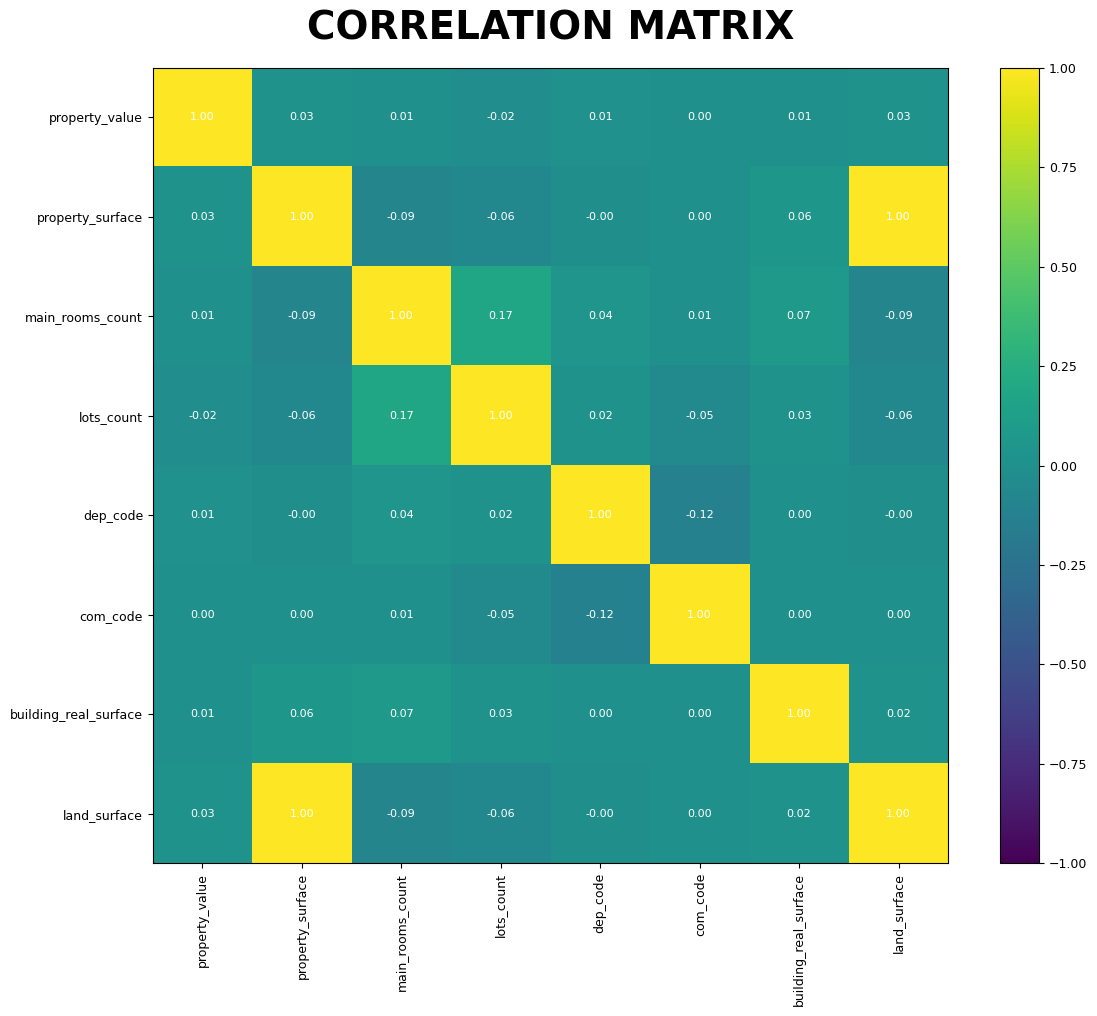


Saved plot to: ../plots/correlation_matrix_ml_valeursfoncieres.png


Numeric columns used for correlation:
['transaction_id', 'property_value', 'dep_code', 'com_code', 'plot_number', 'lots_count', 'lots_surfaces_sum', 'building_real_surface', 'main_rooms_count', 'land_surface', 'property_surface', 'value_per_m2']
Processing chunk 1...
Chunk 1 kept rows: 166,928
Processing chunk 2...
Chunk 2 kept rows: 177,233


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\3078119699.py:39: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 3...
Chunk 3 kept rows: 163,522
Processing chunk 4...
Chunk 4 kept rows: 159,889
Processing chunk 5...
Chunk 5 kept rows: 174,249
Processing chunk 6...
Chunk 6 kept rows: 180,779
Processing chunk 7...
Chunk 7 kept rows: 167,415
Processing chunk 8...
Chunk 8 kept rows: 160,336
Processing chunk 9...
Chunk 9 kept rows: 174,980
Processing chunk 10...
Chunk 10 kept rows: 138,252
Processing chunk 11...
Chunk 11 kept rows: 171,154
Processing chunk 12...
Chunk 12 kept rows: 154,675
Processing chunk 13...
Chunk 13 kept rows: 146,419
Processing chunk 14...
Chunk 14 kept rows: 185,790
Processing chunk 15...
Chunk 15 kept rows: 183,641
Processing chunk 16...
Chunk 16 kept rows: 178,970


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\3078119699.py:39: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 17...
Chunk 17 kept rows: 137,931
Processing chunk 18...
Chunk 18 kept rows: 158,622
Processing chunk 19...
Chunk 19 kept rows: 159,176
Processing chunk 20...
Chunk 20 kept rows: 169,641
Processing chunk 21...
Chunk 21 kept rows: 168,583
Processing chunk 22...
Chunk 22 kept rows: 180,745
Processing chunk 23...
Chunk 23 kept rows: 180,894
Processing chunk 24...
Chunk 24 kept rows: 174,117
Processing chunk 25...
Chunk 25 kept rows: 181,886
Processing chunk 26...
Chunk 26 kept rows: 145,323
Processing chunk 27...
Chunk 27 kept rows: 171,401
Processing chunk 28...
Chunk 28 kept rows: 148,054
Processing chunk 29...
Chunk 29 kept rows: 158,079
Processing chunk 30...
Chunk 30 kept rows: 162,996
Processing chunk 31...
Chunk 31 kept rows: 184,717
Processing chunk 32...
Chunk 32 kept rows: 125,443
Processing chunk 33...
Chunk 33 kept rows: 130,681
Processing chunk 34...
Chunk 34 kept rows: 159,088
Processing chunk 35...
Chunk 35 kept rows: 144,373
Processing chunk 36...
Chunk 36

...

Processing chunk 62...
Chunk 62 kept rows: 156,263
Processing chunk 63...
Chunk 63 kept rows: 156,667
Processing chunk 64...
Chunk 64 kept rows: 159,324
Processing chunk 65...
Chunk 65 kept rows: 169,144
Processing chunk 66...
Chunk 66 kept rows: 174,439
Processing chunk 67...
Chunk 67 kept rows: 179,620
Processing chunk 68...
Chunk 68 kept rows: 176,301
Processing chunk 69...
Chunk 69 kept rows: 172,894
Processing chunk 70...
Chunk 70 kept rows: 155,775
Processing chunk 71...
Chunk 71 kept rows: 146,415
Processing chunk 72...
Chunk 72 kept rows: 163,638
Processing chunk 73...
Chunk 73 kept rows: 163,737
Processing chunk 74...
Chunk 74 kept rows: 156,322
Processing chunk 75...
Chunk 75 kept rows: 122,530
Processing chunk 76...
Chunk 76 kept rows: 148,259
Processing chunk 77...
Chunk 77 kept rows: 155,296
Processing chunk 78...
Chunk 78 kept rows: 157,874
Processing chunk 79...
Chunk 79 kept rows: 183,774
Processing chunk 80...
Chunk 80 kept rows: 177,714


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\3078119699.py:39: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 81...
Chunk 81 kept rows: 140,998
Processing chunk 82...
Chunk 82 kept rows: 158,063
Processing chunk 83...
Chunk 83 kept rows: 166,879
Processing chunk 84...
Chunk 84 kept rows: 176,056
Processing chunk 85...
Chunk 85 kept rows: 179,786
Processing chunk 86...
Chunk 86 kept rows: 175,011
Processing chunk 87...
Chunk 87 kept rows: 164,968
Processing chunk 88...
Chunk 88 kept rows: 157,558
Processing chunk 89...
Chunk 89 kept rows: 143,236
Processing chunk 90...
Chunk 90 kept rows: 165,721
Processing chunk 91...
Chunk 91 kept rows: 181,313
Processing chunk 92...
Chunk 92 kept rows: 112,070
Processing chunk 93...
Chunk 93 kept rows: 137,655
Processing chunk 94...
Chunk 94 kept rows: 160,491


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\3078119699.py:39: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 95...
Chunk 95 kept rows: 165,611
Processing chunk 96...
Chunk 96 kept rows: 164,679
Processing chunk 97...
Chunk 97 kept rows: 179,068
Processing chunk 98...
Chunk 98 kept rows: 154,140
Processing chunk 99...
Chunk 99 kept rows: 163,168
Processing chunk 100...
Chunk 100 kept rows: 59,884
Total valid rows used: 16,104,870

Correlation matrix:
                       transaction_id  property_value  dep_code  com_code  \
transaction_id               1.000000        0.000066 -0.000481 -0.008347   
property_value               0.000066        1.000000  0.008215  0.004088   
dep_code                    -0.000481        0.008215  1.000000 -0.120676   
com_code                    -0.008347        0.004088 -0.120676  1.000000   
plot_number                  0.016445       -0.016092  0.057507 -0.028194   
lots_count                  -0.019914       -0.015165  0.022256 -0.048016   
lots_surfaces_sum           -0.007366        0.003333  0.009051 -0.017966   
building_real_surface 

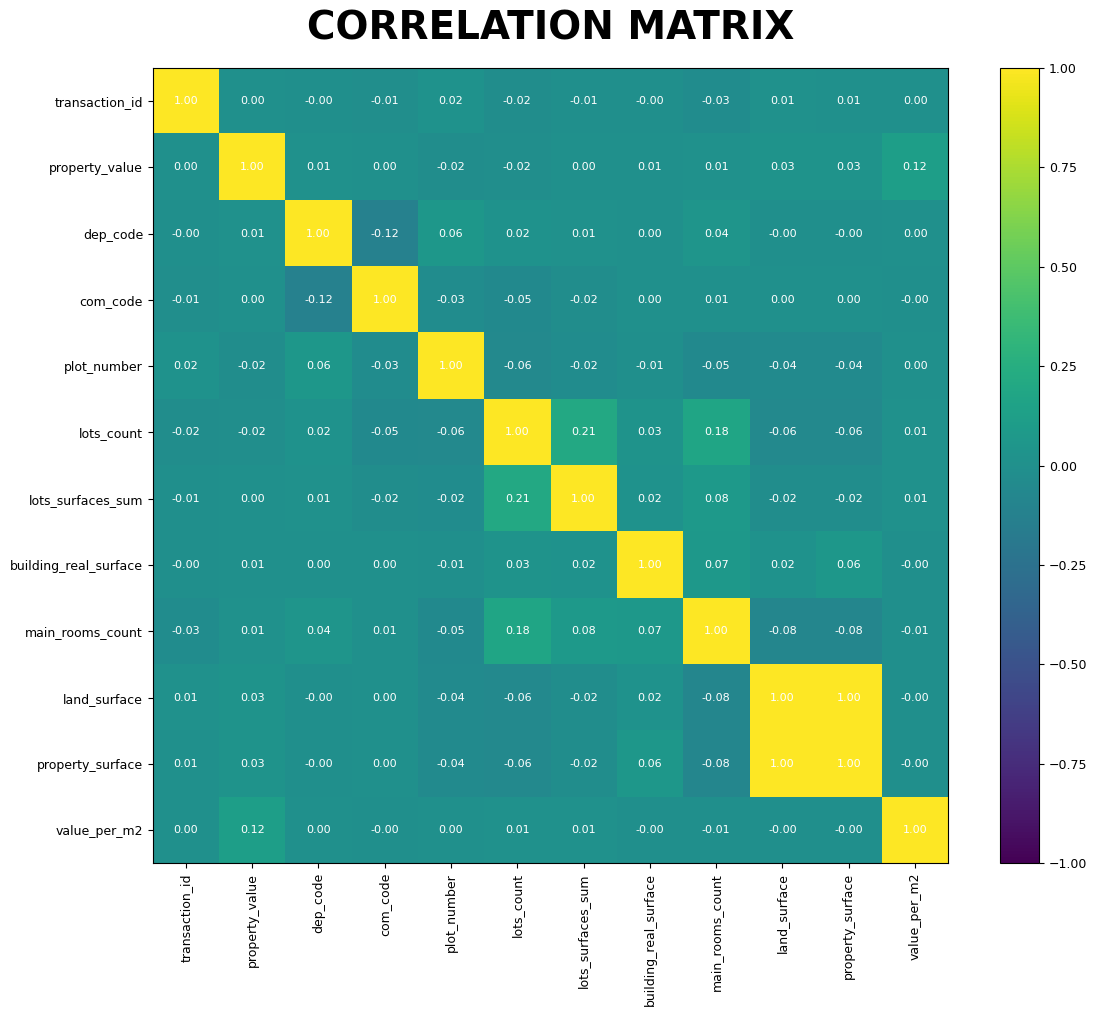


Saved plot to: ../plots/correlation_matrix_ml_valeursfoncieres.png


C:\Users\sboub\AppData\Local\Temp\ipykernel_6508\3646503622.py:19: DtypeWarning: Columns (4,6,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_FILE)


MemoryError: Unable to allocate 2.08 GiB for an array with shape (14, 19908349) and data type object

Processing chunk 1...


MemoryError: Unable to allocate 1.53 MiB for an array with shape (200000,) and data type int64

Numeric columns used for correlation:
['property_value', 'property_surface', 'main_rooms_count', 'lots_count', 'dep_code', 'com_code', 'building_real_surface', 'land_surface']
Processing chunk 1...
Chunk 1 kept rows: 200,000
Processing chunk 2...
Chunk 2 kept rows: 200,000


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\716527447.py:37: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 3...
Chunk 3 kept rows: 193,078
Processing chunk 4...
Chunk 4 kept rows: 200,000
Processing chunk 5...
Chunk 5 kept rows: 200,000
Processing chunk 6...
Chunk 6 kept rows: 200,000
Processing chunk 7...
Chunk 7 kept rows: 200,000
Processing chunk 8...
Chunk 8 kept rows: 200,000
Processing chunk 9...
Chunk 9 kept rows: 200,000
Processing chunk 10...
Chunk 10 kept rows: 200,000
Processing chunk 11...
Chunk 11 kept rows: 200,000
Processing chunk 12...
Chunk 12 kept rows: 200,000
Processing chunk 13...
Chunk 13 kept rows: 200,000


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\716527447.py:37: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 14...
Chunk 14 kept rows: 185,725
Processing chunk 15...
Chunk 15 kept rows: 200,000
Processing chunk 16...
Chunk 16 kept rows: 200,000
Processing chunk 17...
Chunk 17 kept rows: 200,000
Processing chunk 18...
Chunk 18 kept rows: 200,000
Processing chunk 19...
Chunk 19 kept rows: 200,000
Processing chunk 20...
Chunk 20 kept rows: 200,000
Processing chunk 21...
Chunk 21 kept rows: 200,000
Processing chunk 22...
Chunk 22 kept rows: 200,000
Processing chunk 23...
Chunk 23 kept rows: 200,000
Processing chunk 24...
Chunk 24 kept rows: 200,000
Processing chunk 25...
Chunk 25 kept rows: 200,000
Processing chunk 26...
Chunk 26 kept rows: 200,000
Processing chunk 27...
Chunk 27 kept rows: 200,000
Processing chunk 28...
Chunk 28 kept rows: 200,000
Processing chunk 29...
Chunk 29 kept rows: 200,000
Processing chunk 30...
Chunk 30 kept rows: 200,000
Processing chunk 31...
Chunk 31 kept rows: 200,000


...

Processing chunk 49...
Chunk 49 kept rows: 186,893
Processing chunk 50...
Chunk 50 kept rows: 200,000
Processing chunk 51...
Chunk 51 kept rows: 200,000
Processing chunk 52...
Chunk 52 kept rows: 200,000
Processing chunk 53...
Chunk 53 kept rows: 200,000
Processing chunk 54...
Chunk 54 kept rows: 200,000
Processing chunk 55...
Chunk 55 kept rows: 200,000
Processing chunk 56...
Chunk 56 kept rows: 200,000
Processing chunk 57...
Chunk 57 kept rows: 200,000
Processing chunk 58...
Chunk 58 kept rows: 200,000
Processing chunk 59...
Chunk 59 kept rows: 200,000
Processing chunk 60...
Chunk 60 kept rows: 200,000
Processing chunk 61...
Chunk 61 kept rows: 200,000
Processing chunk 62...
Chunk 62 kept rows: 200,000


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\716527447.py:37: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 63...
Chunk 63 kept rows: 187,965
Processing chunk 64...
Chunk 64 kept rows: 200,000
Processing chunk 65...
Chunk 65 kept rows: 200,000
Processing chunk 66...
Chunk 66 kept rows: 200,000
Processing chunk 67...
Chunk 67 kept rows: 200,000
Processing chunk 68...
Chunk 68 kept rows: 200,000
Processing chunk 69...
Chunk 69 kept rows: 200,000
Processing chunk 70...
Chunk 70 kept rows: 200,000
Processing chunk 71...
Chunk 71 kept rows: 200,000
Processing chunk 72...
Chunk 72 kept rows: 200,000
Processing chunk 73...
Chunk 73 kept rows: 200,000


C:\Users\sboub\AppData\Local\Temp\ipykernel_15024\716527447.py:37: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_idx, chunk in enumerate(


Processing chunk 74...
Chunk 74 kept rows: 194,212
Processing chunk 75...
Chunk 75 kept rows: 200,000
Processing chunk 76...
Chunk 76 kept rows: 200,000
Processing chunk 77...
Chunk 77 kept rows: 200,000
Processing chunk 78...
Chunk 78 kept rows: 127,998


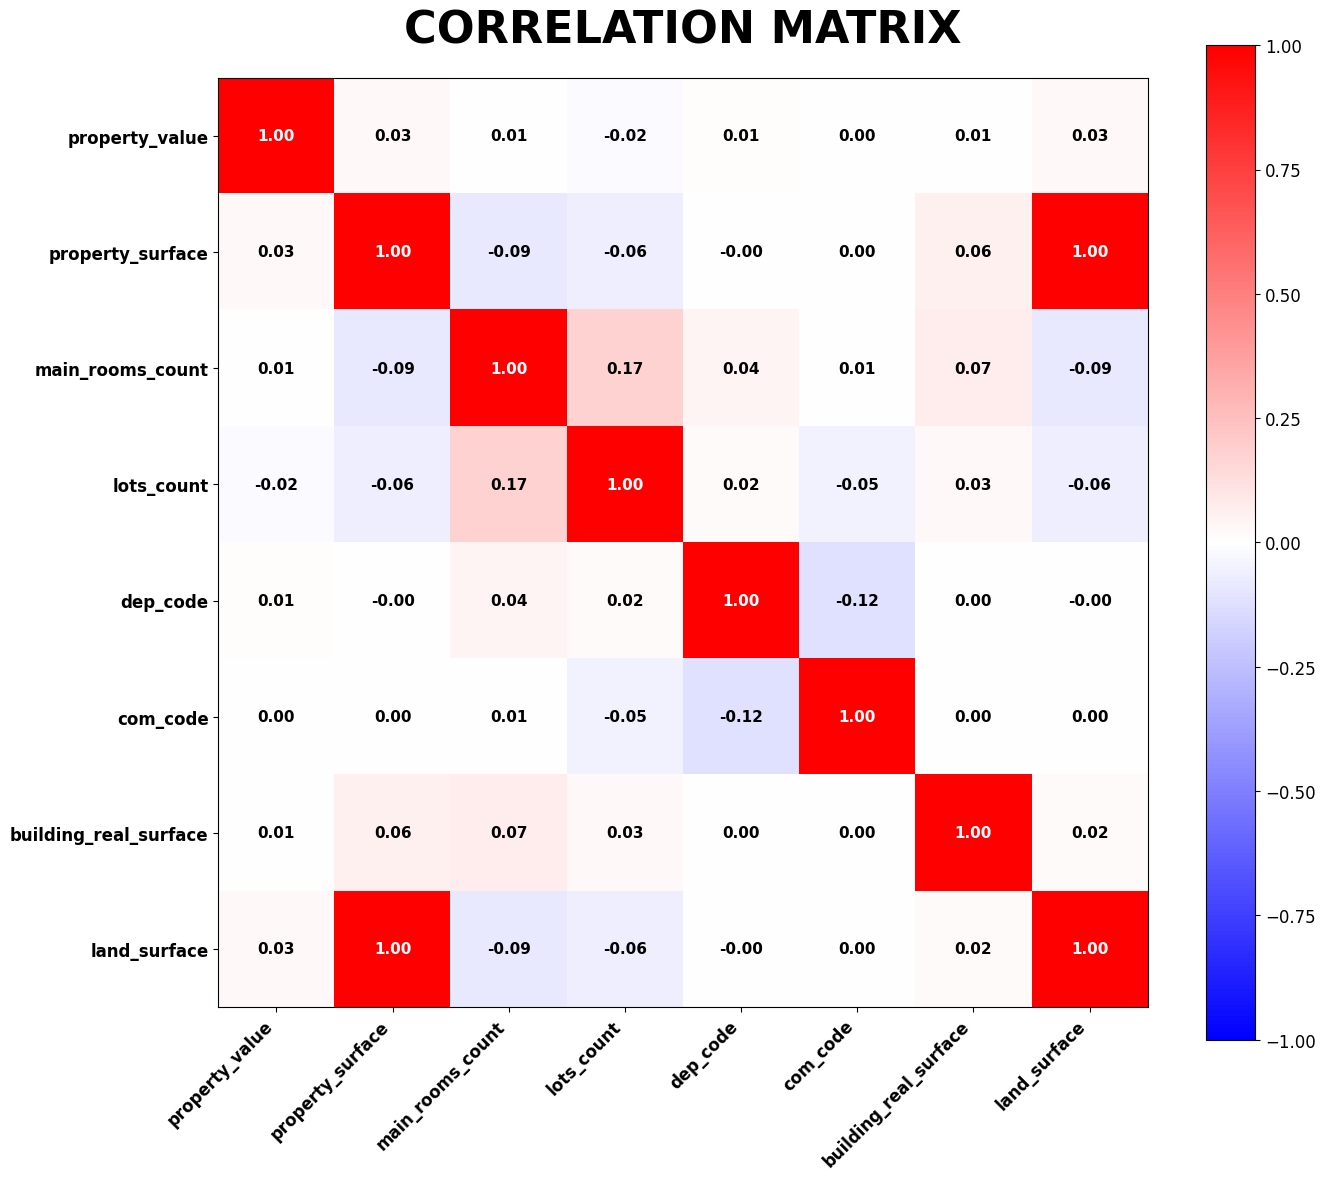


Saved plot to: ../plots/correlation_matrix_ml_valeursfoncieres.png


Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
Processing chunk 34...
Processing chunk 35...
Processing chunk 36...
Processing chunk 37...
Processing chunk 38...
Processing chunk 39...
Processing chunk 40...
Processing chunk 41...
Processing chunk 42...
Processing chunk 43...
Processing chunk 44.

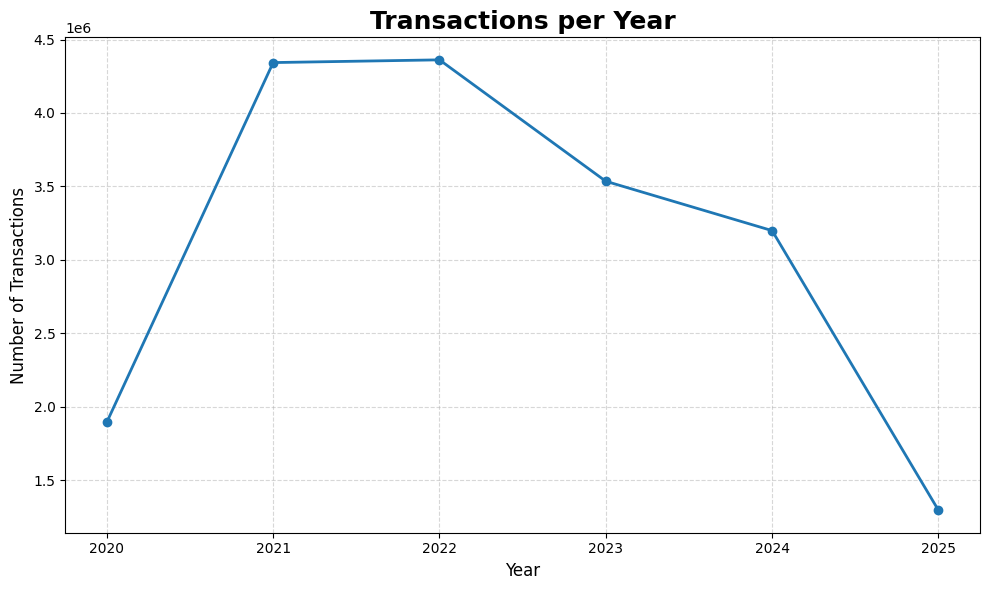

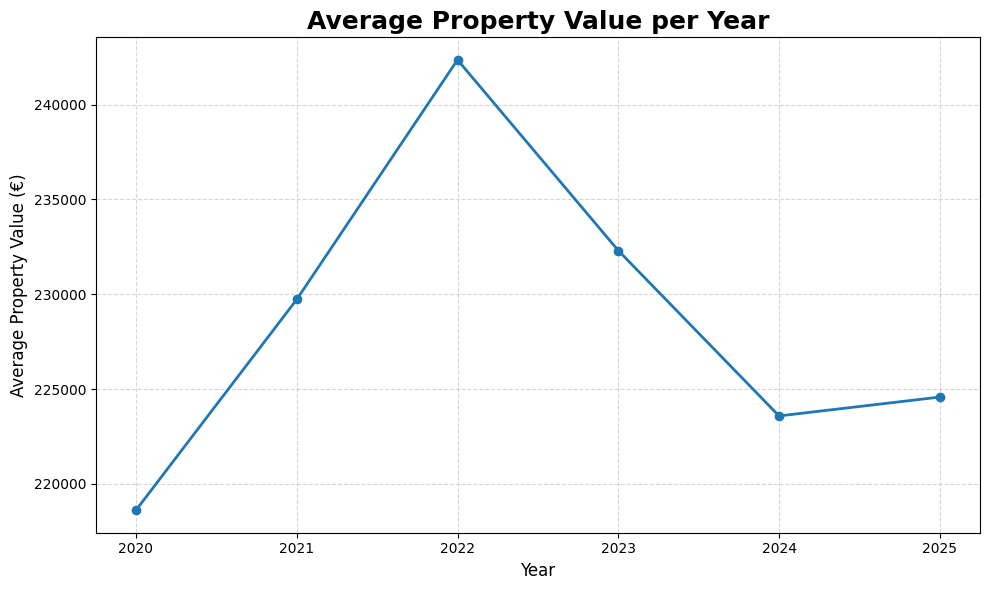

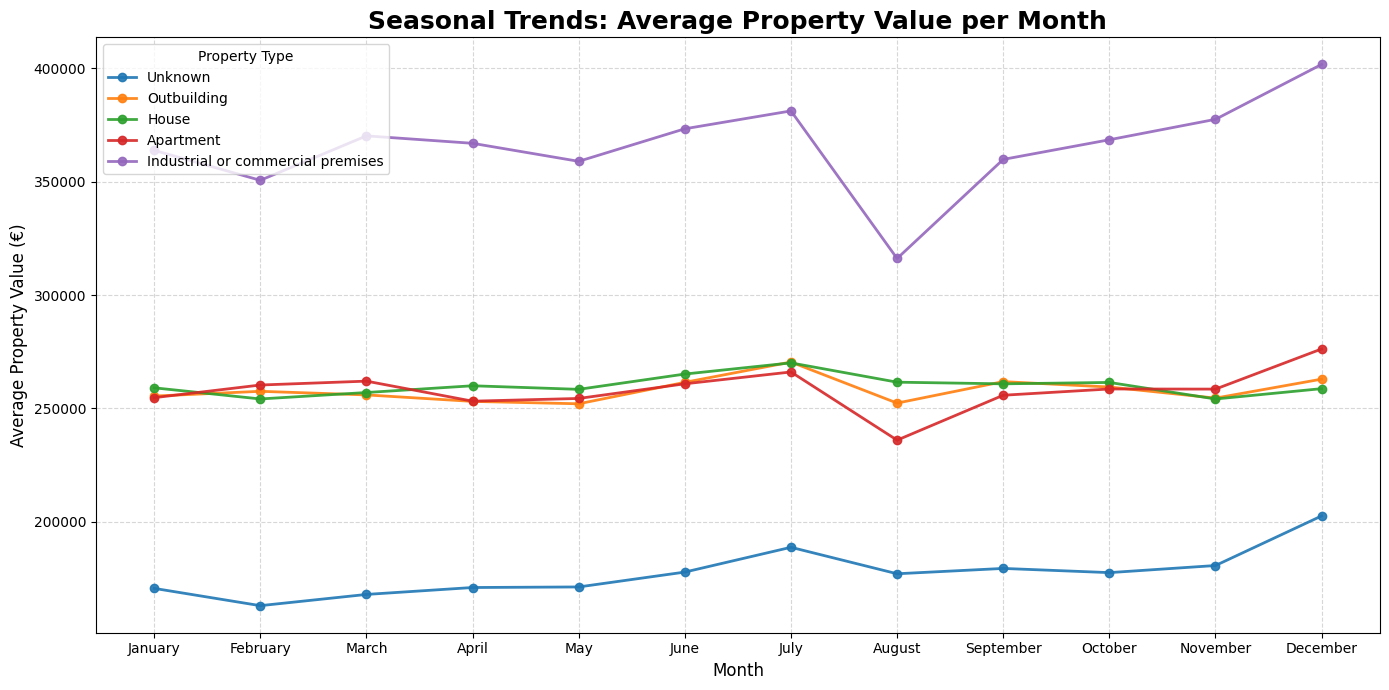

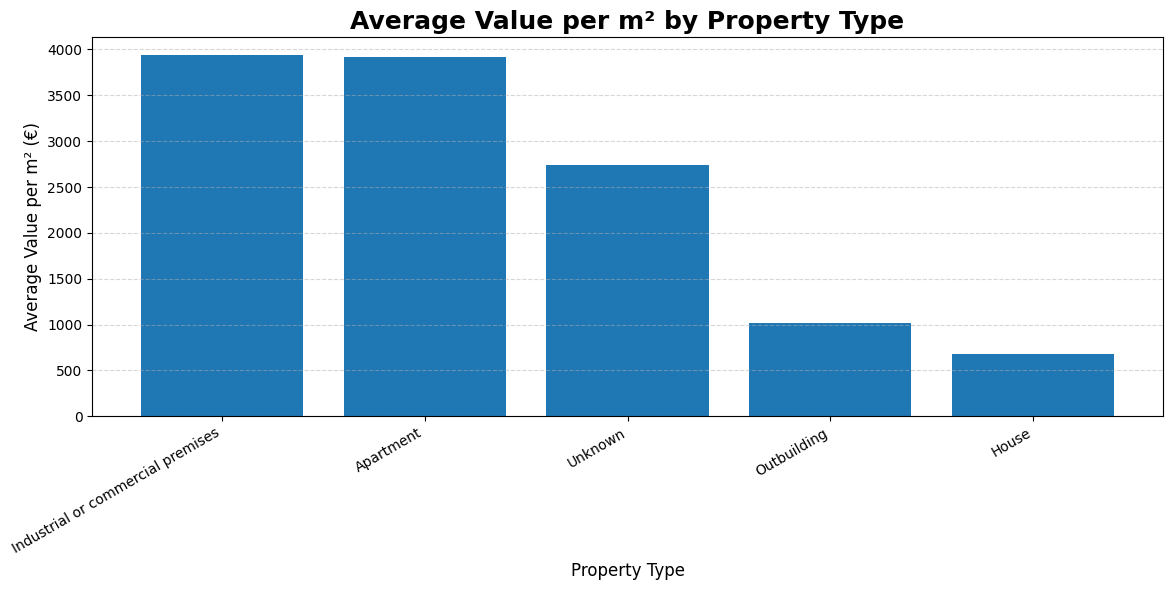

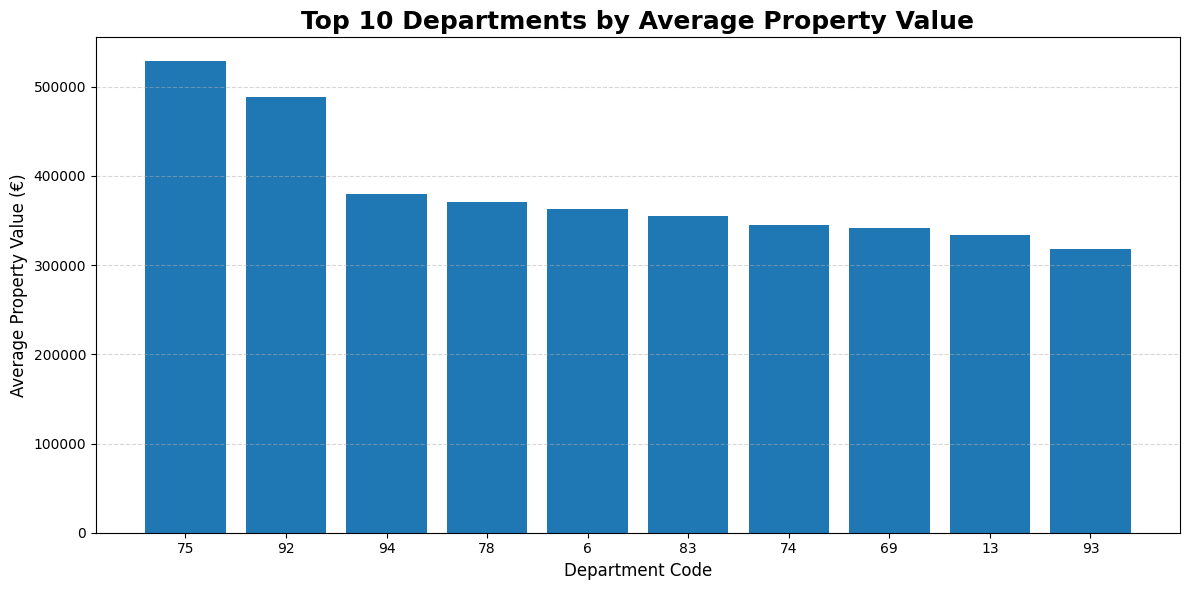

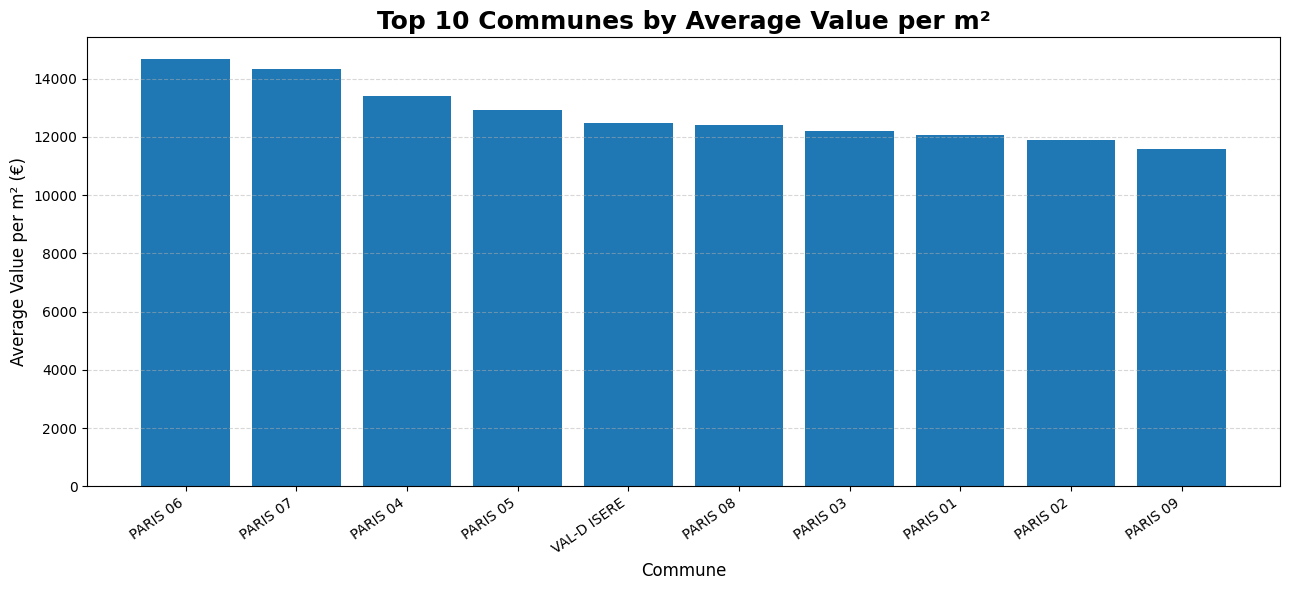

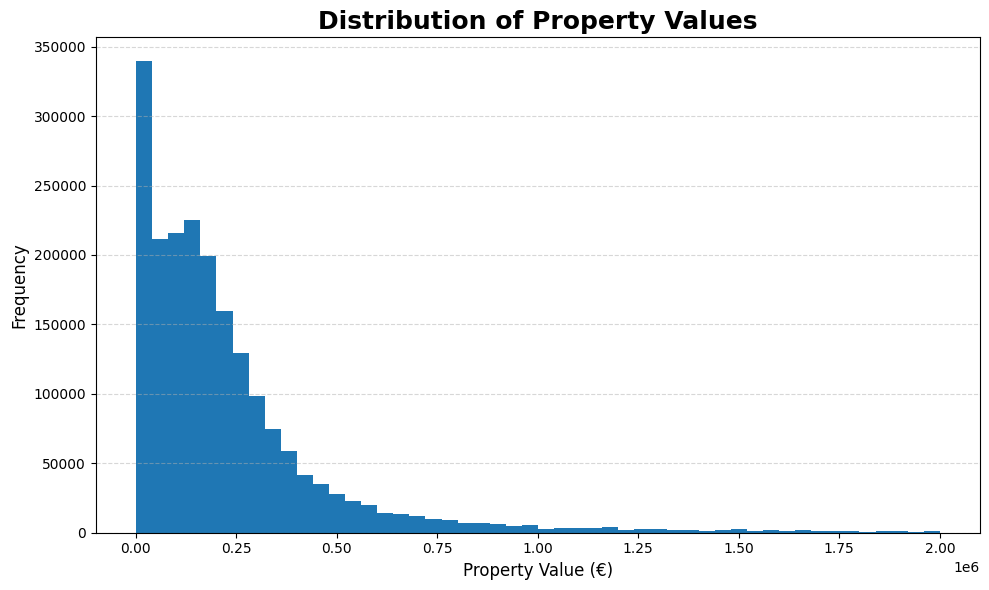

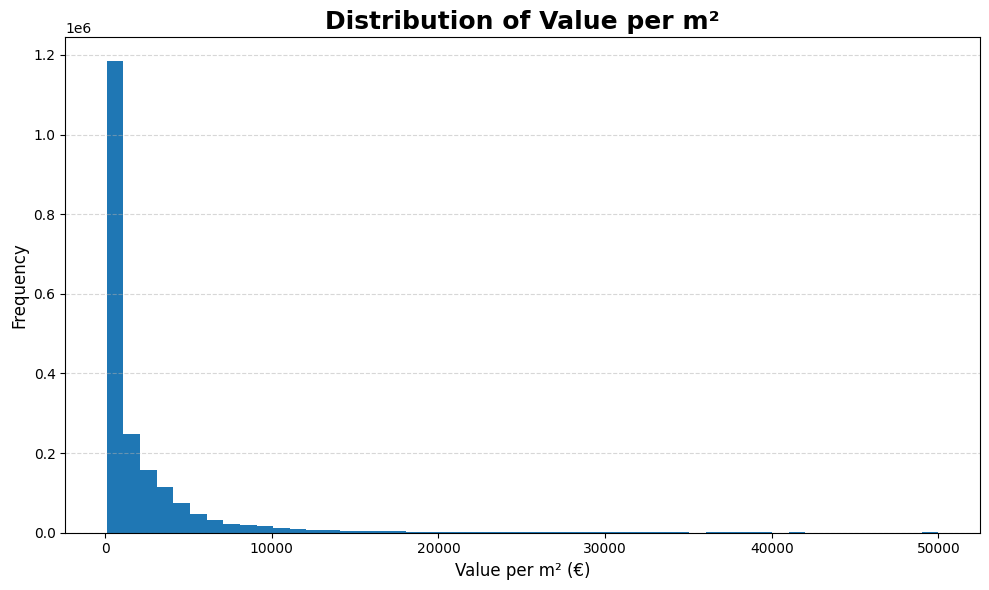

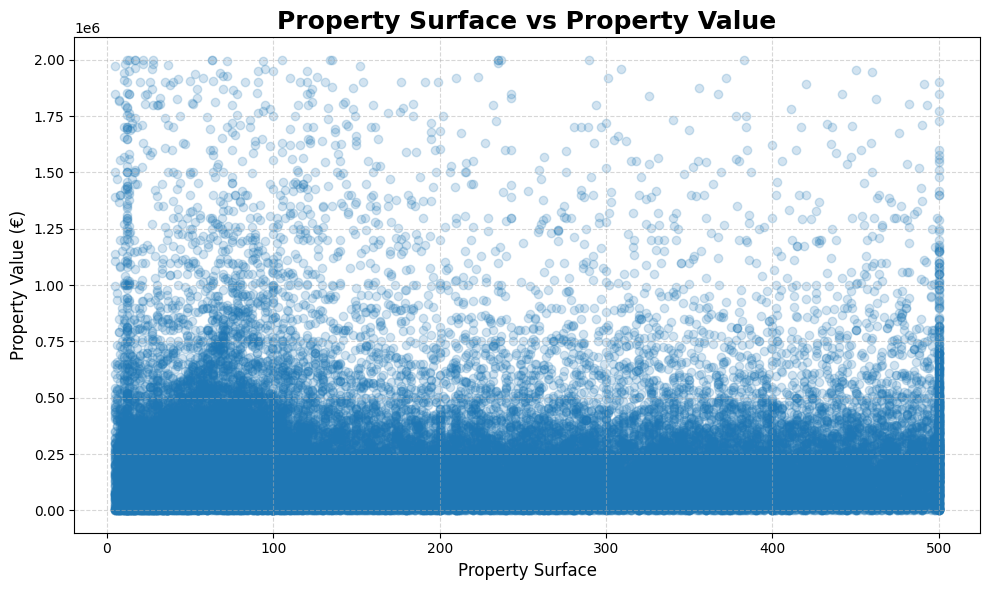

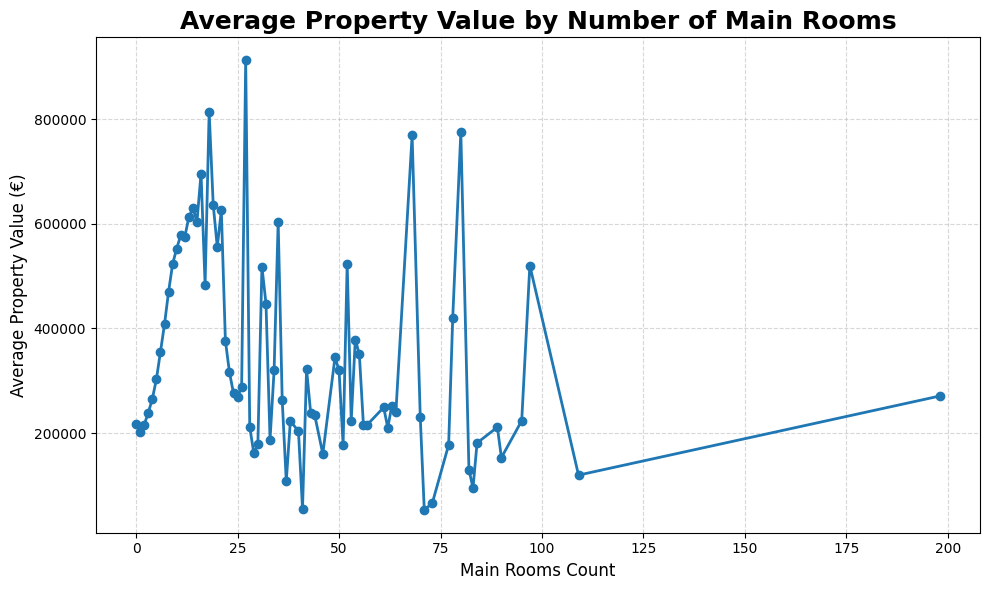

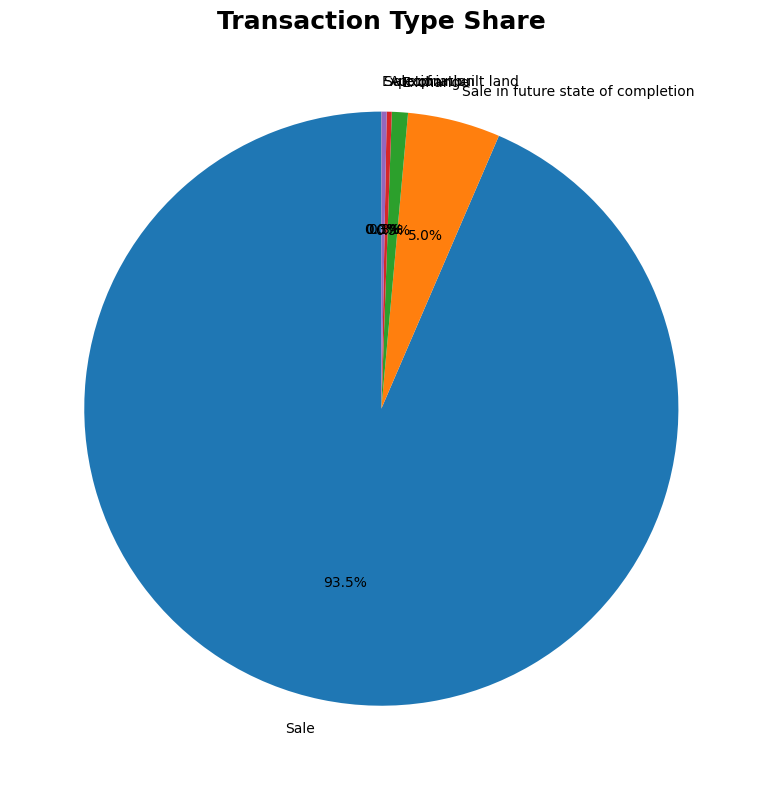

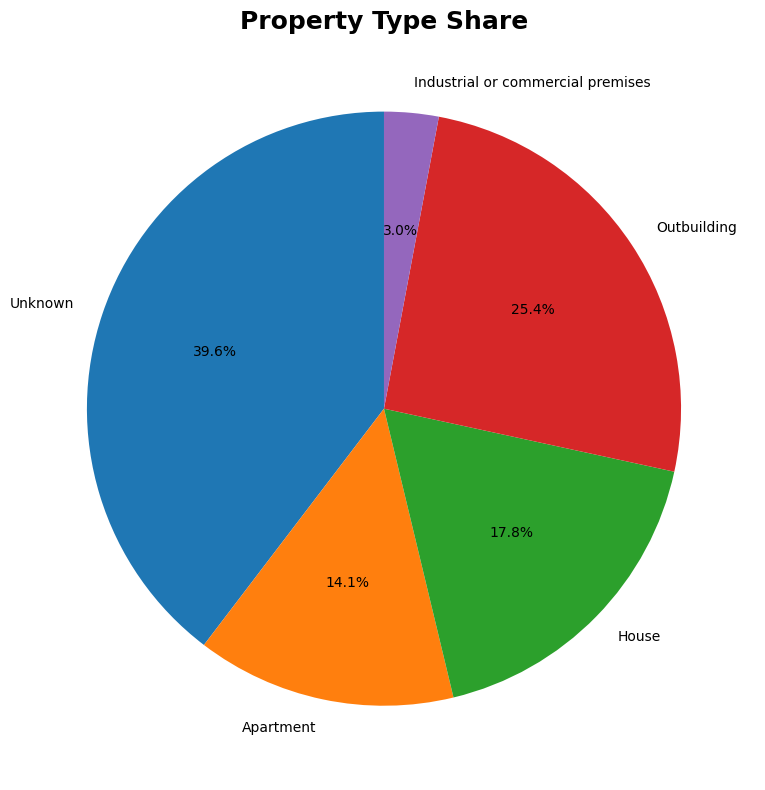

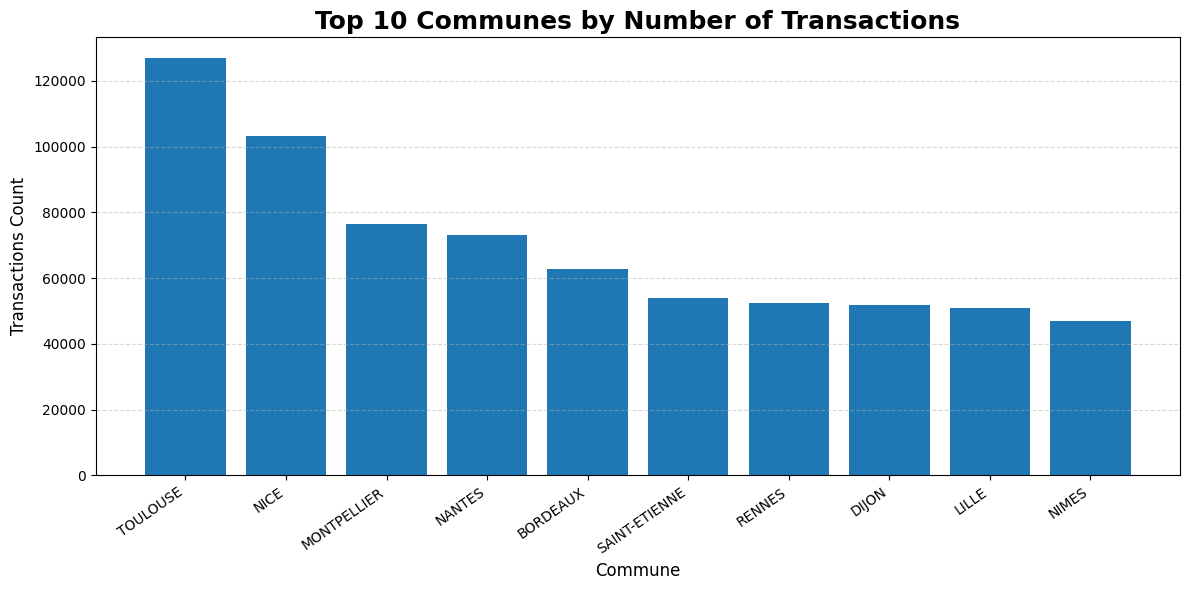

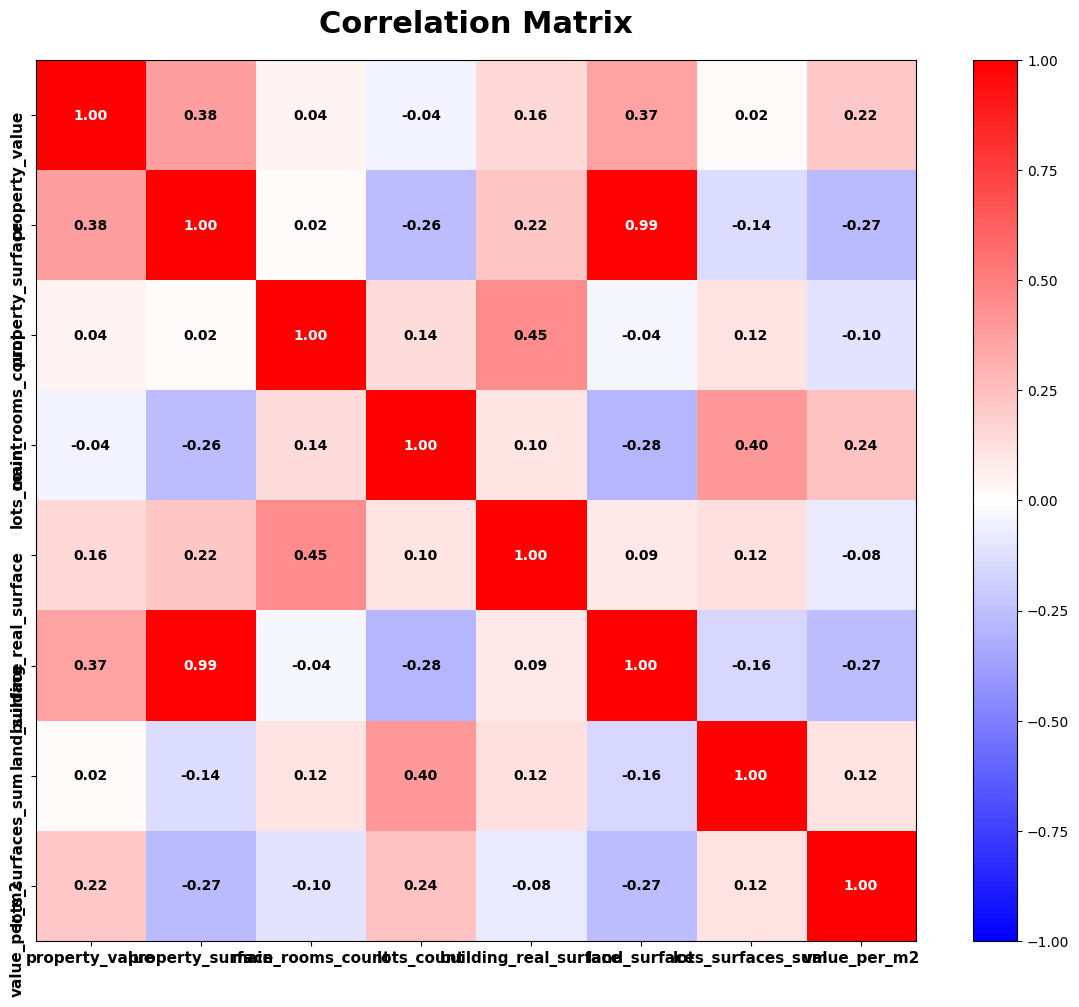

C:\Users\sboub\AppData\Local\Temp\ipykernel_16684\476575512.py:558: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


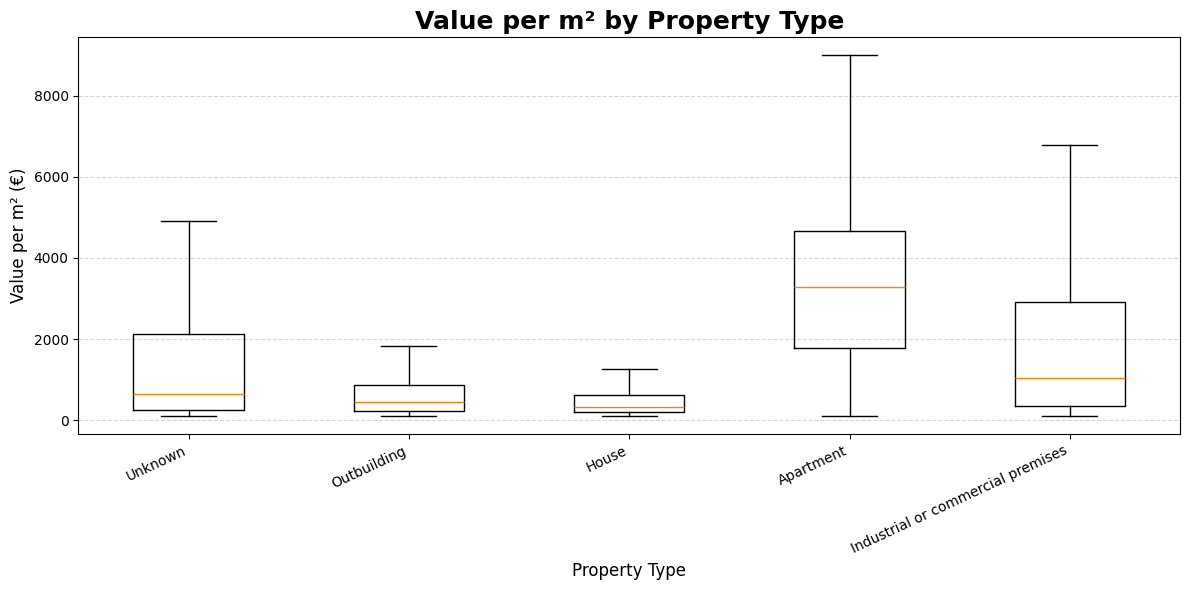


✅ All chunk-based presentation plots saved in: ../plots


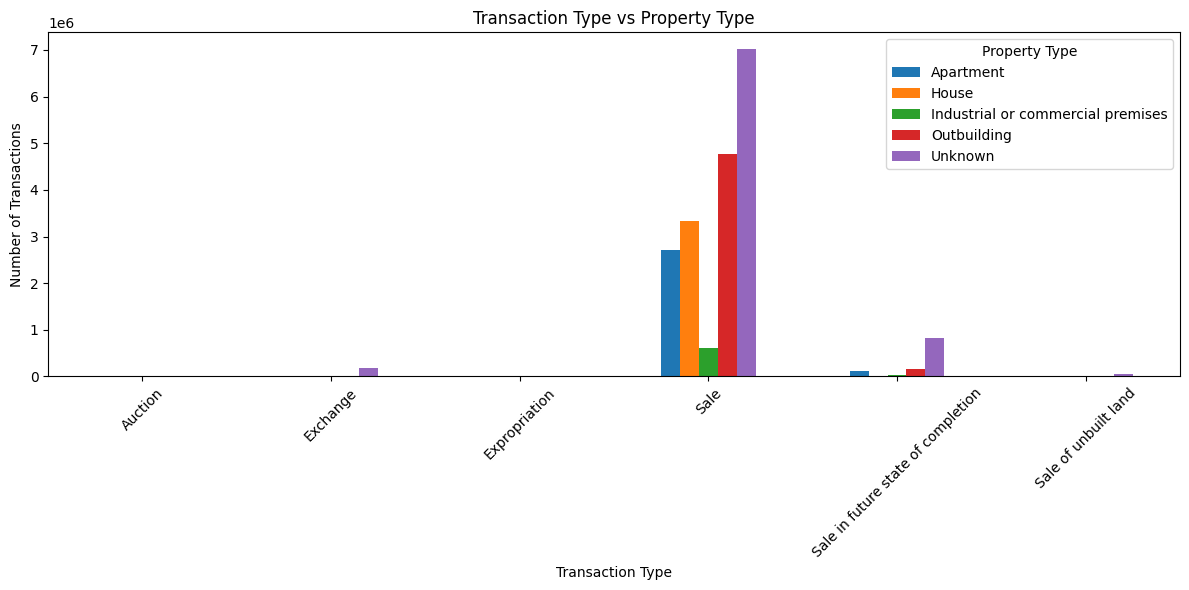

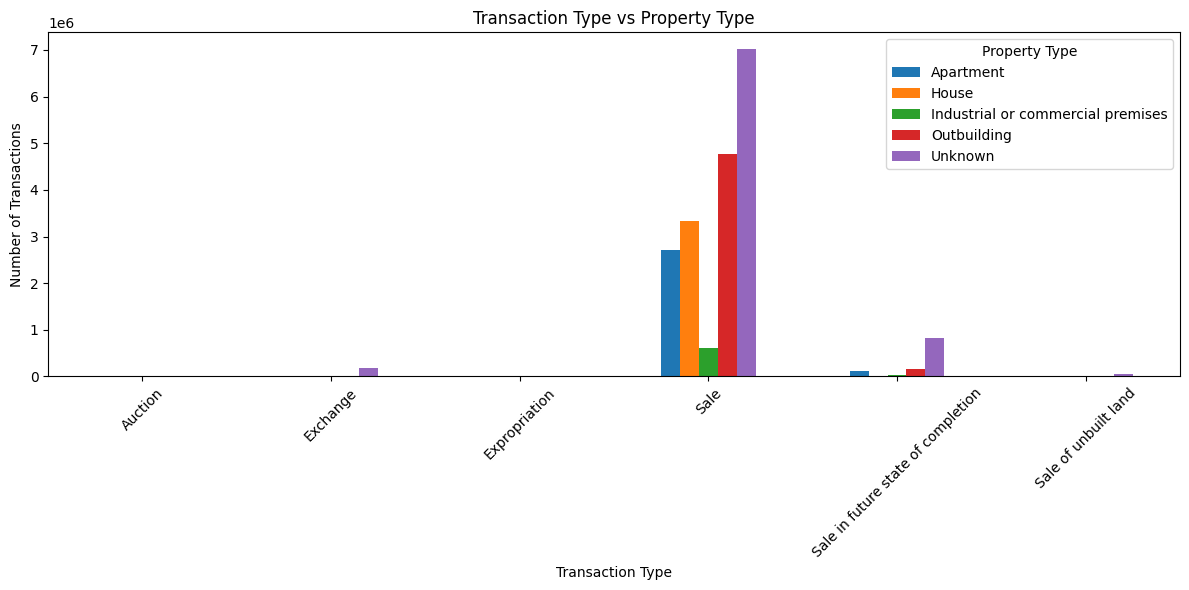

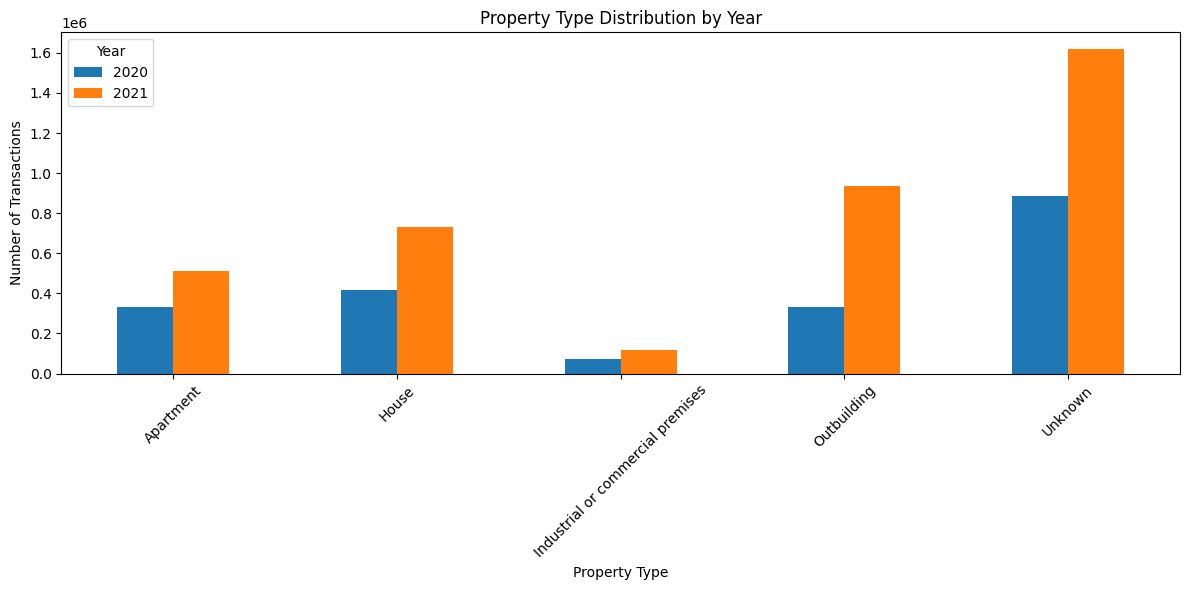

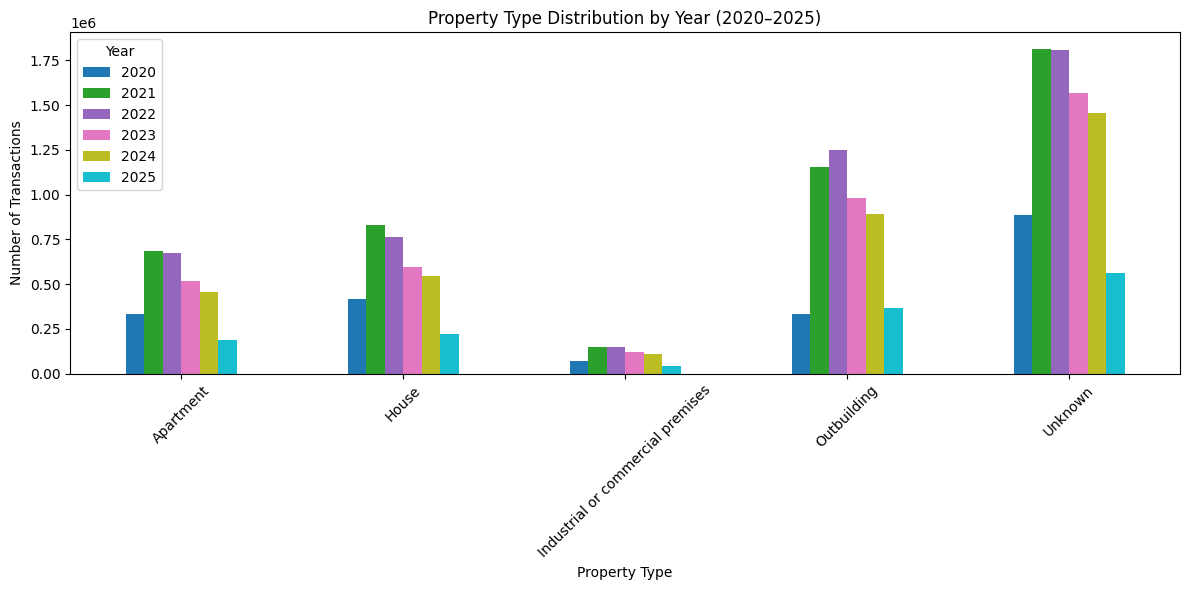